In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import clear_output
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import Counter
import requests as re
import seaborn as sns
import statistics

In [43]:
path="/Users/mattgonzales/downloads/Labeled Turnips - turnip_weekly_clean.csv"
turnip=pd.read_csv(path)

In [44]:
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [45]:
OriginalTurnips = turnip.copy()
OriginalTurnips = OriginalTurnips.drop("week", axis=1)
TurnipLabel = turnip["Label"]
turnip=turnip.drop(["week", "Label"], axis=1)
feature_names = turnip.columns
print(OriginalTurnips)
print(turnip)

     Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
0         96.0       92.0       87.0        82.0          79            74   
1        109.0       88.0       84.0        80.0          76            73   
2        106.0       96.0       91.0        86.0          83            79   
4        107.0       80.0       99.0       123.0         168           183   
6         96.0       86.0       83.0       132.0         139           512   
..         ...        ...        ...         ...         ...           ...   
105      110.0       98.0       94.0        90.0          86            81   
106      108.0      141.0      110.0       151.0         115           144   
107      106.0      103.0       77.0        69.0          64           117   
108      103.0      110.0      138.0       118.0         108           144   
109       93.0       75.0       66.0        58.0         129            98   

     Wednesday_PM  Thursday_AM  Thursday_PM  Friday_AM  Friday_

In [46]:
MyDic = {
    "Fluctuating": 0,
    "Small Spike": 1,
    "Large Spike": 2,
    "Decreasing": 3,
}
TurnipLabel = TurnipLabel.map(MyDic)

In [47]:

scaler = StandardScaler()

turnip = scaler.fit_transform(turnip)
print(type(turnip))

<class 'numpy.ndarray'>


In [48]:
pca = PCA(n_components=3)
t_pca = pca.fit_transform(turnip)

In [33]:
# Initialize KMeans with the number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(t_pca)  # or X_scaled if not reducing dimensions

# Cluster labels for each point
labels = kmeans.labels_

# Cluster centers
centers = kmeans.cluster_centers_

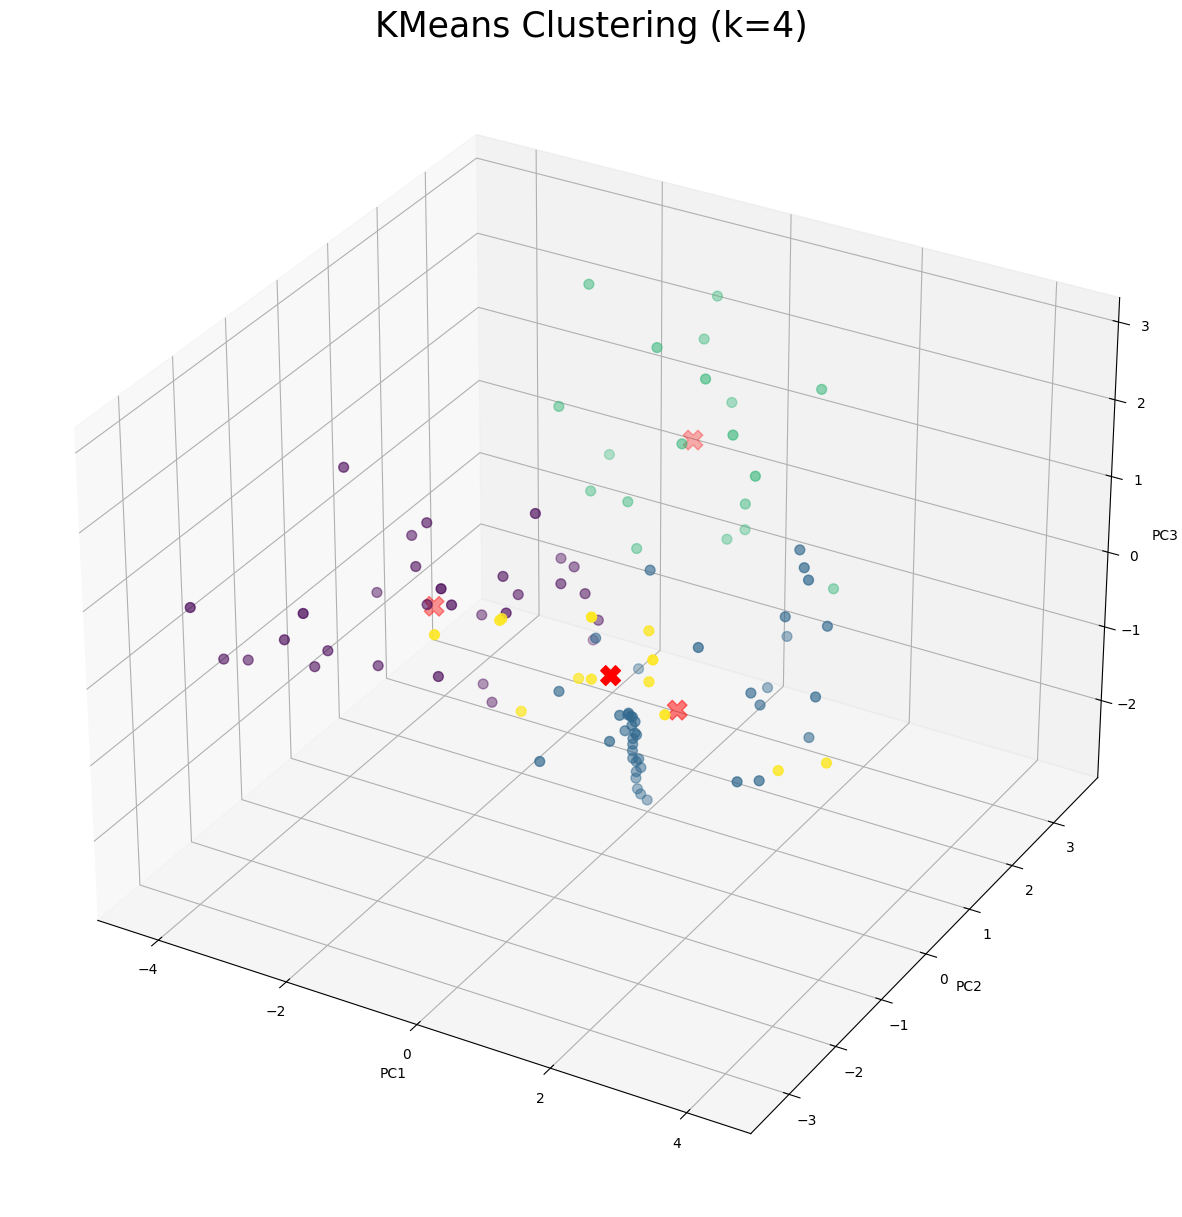

In [38]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# Assume X_pca is 3D (n_samples x 3) and labels/centers are from KMeans
fig = plt.figure(figsize=(15, 20))
ax = fig.add_subplot(111, projection='3d')

# Plot the points, colored by cluster
scatter = ax.scatter(
    t_pca[:, 0], t_pca[:, 1], t_pca[:, 2], 
    c=labels, cmap='viridis', s=50
)

# Plot the cluster centers
ax.scatter(
    centers[:, 0], centers[:, 1], centers[:, 2], 
    c='red', s=200, marker='X'
)

ax.set_title("KMeans Clustering (k=4)", fontsize=25)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.savefig("3D_KMeans.png")
plt.show()

In [39]:
from sklearn.metrics import silhouette_score
sil_scores = []
k_values = range(2, 7)  # try k = 2 to 7
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(turnip)
    score = silhouette_score(turnip, labels)
    sil_scores.append(score)

# Print Silhouette scores
for k, score in zip(k_values, sil_scores):
    print(f"k={k}, Silhouette Score={score:.3f}")

# Pick top 3 k values with highest silhouette scores
top_k_indices = np.argsort(sil_scores)[-3:]
smart_k_values = [k_values[i] for i in top_k_indices]
print("Three smart k values:", smart_k_values)

k=2, Silhouette Score=0.140
k=3, Silhouette Score=0.193
k=4, Silhouette Score=0.227
k=5, Silhouette Score=0.252
k=6, Silhouette Score=0.257
Three smart k values: [4, 5, 6]


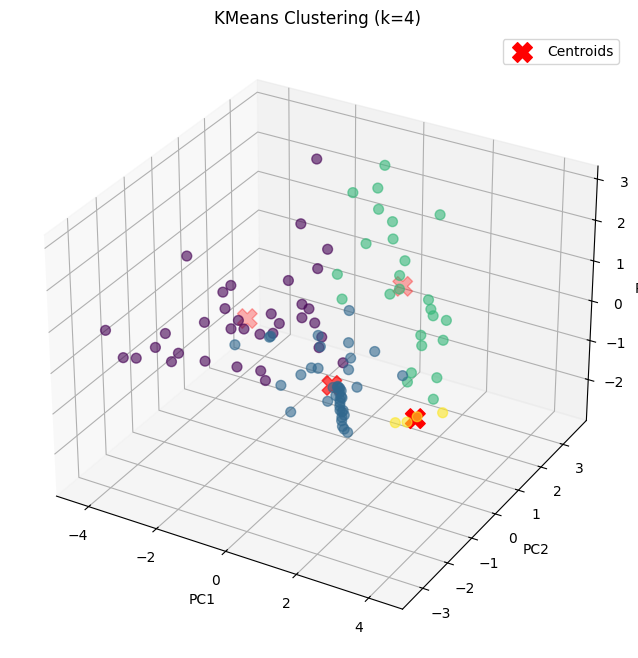

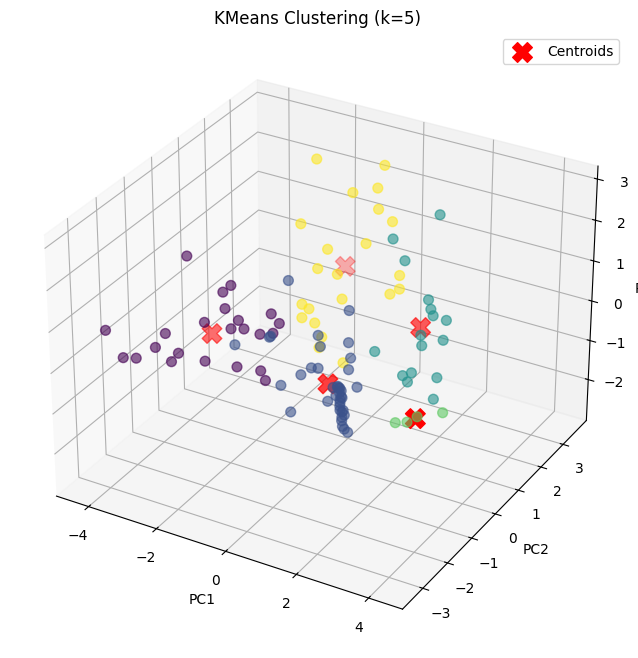

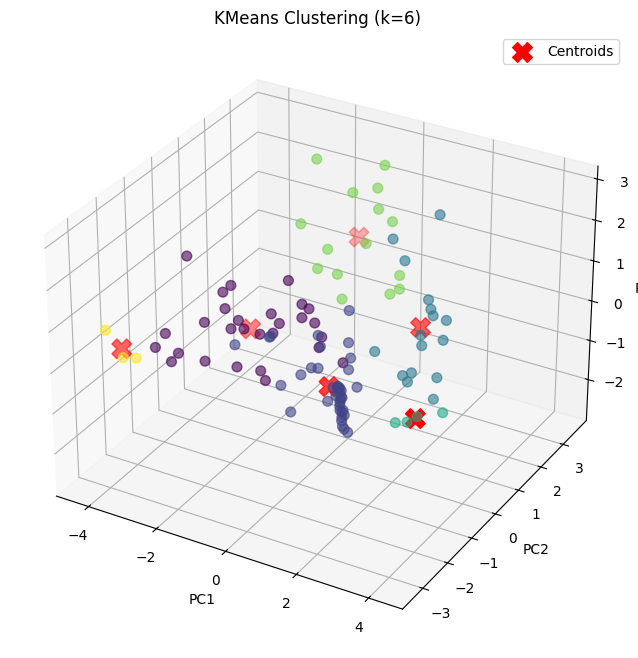

In [40]:
for k in smart_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(turnip)
    centers = kmeans.cluster_centers_
    
    # Project centers to PCA space
    centers_pca = pca.transform(centers)
    
    # 3D plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot points colored by original labels
    scatter = ax.scatter(
        t_pca[:,0], t_pca[:,1], t_pca[:,2], 
        c=labels, cmap='viridis', s=50, alpha=0.6
    )
    
    # Plot cluster centers
    ax.scatter(
        centers_pca[:,0], centers_pca[:,1], centers_pca[:,2],
        c='red', s=200, marker='X', label='Centroids'
    )
    
    ax.set_title(f"KMeans Clustering (k={k})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.legend()
    plt.savefig("silhouette_score.png")
    plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

In [49]:
Z = linkage(turnip, method='ward')


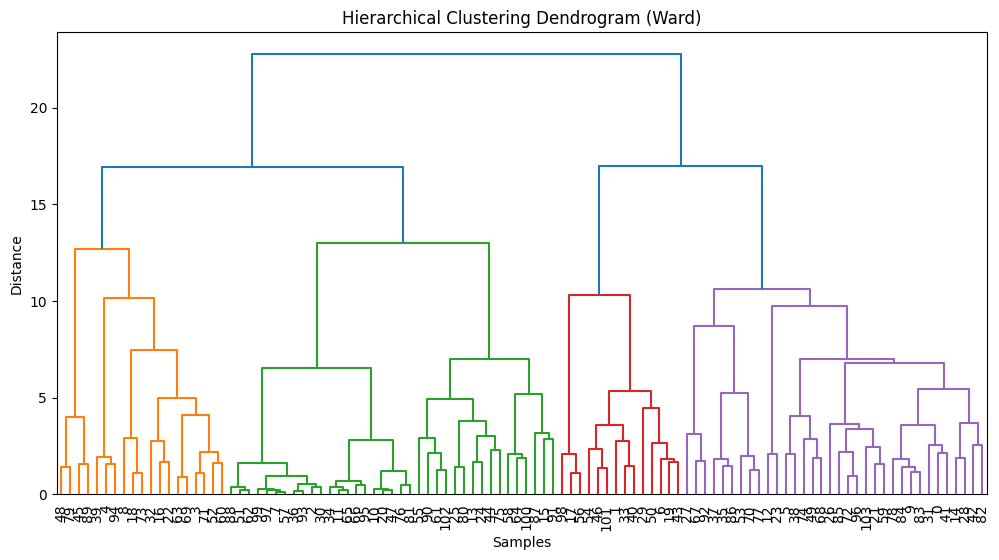

In [51]:
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=None, leaf_rotation=90, leaf_font_size=10, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.savefig("dendrogram.png")
plt.show()

In [18]:
# Form flat clusters from dendrogram (e.g., 3 clusters)
clusters = fcluster(Z, t=4, criterion='maxclust')
print(clusters)

[4 3 2 1 1 4 3 2 1 4 2 2 4 2 4 2 1 3 1 3 2 4 1 4 2 2 4 4 4 3 2 4 1 3 2 4 2
 4 4 1 3 4 4 3 2 1 3 2 1 4 3 2 1 4 3 2 3 2 2 4 1 2 2 1 2 2 2 4 4 1 4 1 4 1
 4 2 2 4 4 1 2 2 4 4 4 4 4 2 2 1 2 2 4 2 1 2 4 2 3 2 2 3 2 4]


In [60]:
from sklearn.cluster import DBSCAN
# eps = neighborhood radius, min_samples = minimum points to form a dense region
dbscan = DBSCAN(eps=2, min_samples=4)
labels = dbscan.fit_predict(turnip)

# DBSCAN labels: -1 means noise/outlier
unique_labels = np.unique(labels)
print("Cluster labels:", unique_labels)

Cluster labels: [-1  0  1  2  3]


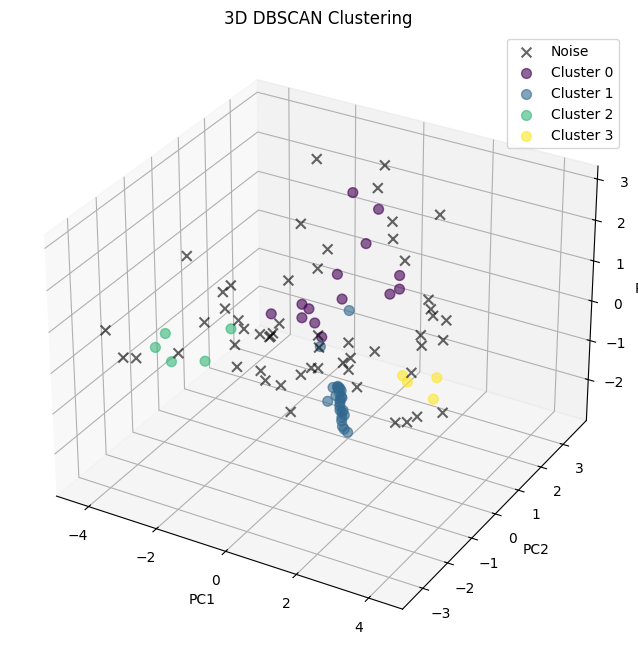

In [63]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for label in unique_labels:
    if label == -1:
        # Noise points
        color = 'black'
        marker = 'x'
        size = 50
    else:
        color = plt.cm.viridis(label / max(unique_labels))
        marker = 'o'
        size = 50
        
    ax.scatter(
        t_pca[labels==label, 0],
        t_pca[labels==label, 1],
        t_pca[labels==label, 2],
        c=[color],
        marker=marker,
        s=size,
        alpha=0.6,
        label=f'Cluster {label}' if label != -1 else 'Noise'
    )

ax.set_title("3D DBSCAN Clustering")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.savefig("DBSCAN.png")
plt.show()